
# Triadic Cell Notebook v25
## Project forward → compute backward → fold forward

This notebook implements the next runtime turn directly.

The working rule is:

1. **project forward**
   - simulate where the current packet state wants to go

2. **compute backward**
   - compare the projected future with the target closure
   - derive correction fields from the mismatch

3. **fold forward**
   - apply those corrections gradually with damping and neighbor coupling
   - let the packet relax into closure rather than jump there

This is the current local runtime analog of protein-like folding.

It is still **not** base-model training.
It is a better controller over the packet field.



## Software meaning

The split remains:

- **LLM / proposer**
  - unchanged
  - proposes candidates only

- **Inner packet CPU**
  - projects local futures
  - holds persistent state
  - accepts fold corrections

- **Outer bridge CPU**
  - chooses action from projected mismatch
  - steers the fold

- **Value layer**
  - late readout only

This notebook compares:

- a **one-step bridge**
- a **forward/backward folding bridge**


In [1]:

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

rng = np.random.default_rng(42)

print("Environment ready.")


Environment ready.



## Canonical packet world


In [2]:

tail_prototypes = np.array([
    [0.92, 0.18, 0.58, 0.22],
    [0.18, 0.90, 0.26, 0.60],
    [0.62, 0.24, 0.90, 0.18],
    [0.22, 0.62, 0.18, 0.88],
], dtype=float)

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))

def top2_margin(scores: np.ndarray):
    order = np.argsort(scores)[::-1]
    top1_idx = int(order[0])
    top1 = float(scores[order[0]])
    top2 = float(scores[order[1]]) if len(order) > 1 else 0.0
    return top1_idx, top1, top1 - top2



## Corruption generator


In [3]:

MODES = [
    "clean",
    "missing_left",
    "missing_right",
    "carry_fracture",
    "bad_carry",
    "ambiguous",
    "noisy",
    "broken",
    "borderline",
    "wrong_class",
]

MODE_WEIGHTS = np.array([0.10, 0.12, 0.12, 0.12, 0.12, 0.12, 0.08, 0.06, 0.08, 0.08], dtype=float)
MODE_WEIGHTS = MODE_WEIGHTS / MODE_WEIGHTS.sum()

def corrupt_tail(base_tail: np.ndarray, mode: str, target_slot: int) -> np.ndarray:
    x = base_tail.copy()

    if mode == "clean":
        x += rng.normal(0.0, 0.02, size=x.shape[0])

    elif mode == "missing_left":
        x[0] *= rng.uniform(0.0, 0.18)
        x += rng.normal(0.0, 0.02, size=x.shape[0])

    elif mode == "missing_right":
        x[3] *= rng.uniform(0.0, 0.18)
        x += rng.normal(0.0, 0.02, size=x.shape[0])

    elif mode == "carry_fracture":
        x[1] = np.clip(x[1] + rng.uniform(0.35, 0.60), 0.0, 1.0)
        x[2] = np.clip(x[2] + rng.normal(0.0, 0.01), 0.0, 1.0)
        x[0] = np.clip(x[0] + rng.normal(0.0, 0.01), 0.0, 1.0)
        x[3] = np.clip(x[3] + rng.normal(0.0, 0.01), 0.0, 1.0)

    elif mode == "bad_carry":
        x[1] = np.clip(x[1] + rng.uniform(0.22, 0.48), 0.0, 1.0)
        x[2] = np.clip(x[2] - rng.uniform(0.08, 0.22), 0.0, 1.0)
        x += rng.normal(0.0, 0.015, size=x.shape[0])

    elif mode == "ambiguous":
        alt = int((target_slot + rng.integers(1, 4)) % len(tail_prototypes))
        x = 0.52 * base_tail + 0.48 * tail_prototypes[alt] + rng.normal(0.0, 0.02, size=x.shape[0])

    elif mode == "noisy":
        mask = rng.random(x.shape[0]) < 0.25
        x[mask] = 0.0
        x += rng.normal(0.0, 0.05, size=x.shape[0])

    elif mode == "broken":
        x = rng.uniform(0.0, 1.0, size=x.shape[0])

    elif mode == "borderline":
        x = 0.85 * base_tail + 0.15 * np.roll(base_tail, 1) + rng.normal(0.0, 0.025, size=x.shape[0])
        x[0] = np.clip(x[0] - 0.08, 0.0, 1.0)
        x[3] = np.clip(x[3] - 0.08, 0.0, 1.0)

    elif mode == "wrong_class":
        alt = int((target_slot + rng.integers(1, 4)) % len(tail_prototypes))
        x = 0.10 * base_tail + 0.90 * tail_prototypes[alt] + rng.normal(0.0, 0.02, size=x.shape[0])

    return np.clip(x, 0.0, 1.0)



## Lattice state


In [4]:

def init_lattice(height: int = 8, width: int = 8):
    truth = rng.integers(0, 4, size=(height, width))
    modes = rng.choice(MODES, size=(height, width), p=MODE_WEIGHTS)

    tail = np.zeros((height, width, 4), dtype=float)
    carry = np.zeros((height, width), dtype=float)
    closure = np.zeros((height, width), dtype=float)
    trace = np.zeros((height, width), dtype=float)

    for i in range(height):
        for j in range(width):
            cls = int(truth[i, j])
            t = corrupt_tail(tail_prototypes[cls], modes[i, j], cls)
            tail[i, j] = t
            carry[i, j] = 0.5 * t[1] + 0.5 * t[2]
            closure[i, j] = cosine_similarity(t, tail_prototypes[cls])
            trace[i, j] = 0.0

    return {
        "truth": truth,
        "modes": modes,
        "tail": tail,
        "carry": carry,
        "closure": closure,
        "trace": trace,
    }

def clone_state(state: dict):
    return {k: np.copy(v) if isinstance(v, np.ndarray) else v for k, v in state.items()}



## Local packet shape


In [5]:

def neighbor_tail_mean(state: dict, i: int, j: int) -> np.ndarray:
    H, W, _ = state["tail"].shape
    neighbors = []
    for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
        ni, nj = i + di, j + dj
        if 0 <= ni < H and 0 <= nj < W:
            neighbors.append(state["tail"][ni, nj])
    if len(neighbors) == 0:
        return np.zeros(4, dtype=float)
    return np.mean(np.stack(neighbors, axis=0), axis=0)

def predict_slot_from_tail(tail_vec: np.ndarray):
    scores = np.array([cosine_similarity(tail_vec, t) for t in tail_prototypes], dtype=float)
    pred_slot, _, margin = top2_margin(scores)
    return pred_slot, float(margin), scores

def packet_shape_features(state: dict, i: int, j: int):
    tail_vec = state["tail"][i, j]
    pred_slot, route_margin, _ = predict_slot_from_tail(tail_vec)
    candidate_tail = tail_prototypes[pred_slot]
    neigh = neighbor_tail_mean(state, i, j)

    left_support = 1.0 - abs(tail_vec[0] - candidate_tail[0])
    hinge_fit = 1.0 - abs(tail_vec[2] - candidate_tail[2])
    right_support = 1.0 - abs(tail_vec[3] - candidate_tail[3])

    carry_target = 0.5 * candidate_tail[1] + 0.5 * candidate_tail[2]
    carry_fit = 1.0 - abs(state["carry"][i, j] - carry_target)

    tail_fit = cosine_similarity(tail_vec, candidate_tail)
    contradiction = 1.0 - tail_fit
    bilateral = 0.5 * (left_support + right_support)
    support_balance = 1.0 - abs(left_support - right_support)
    neighbor_agreement = cosine_similarity(tail_vec, neigh) if np.linalg.norm(neigh) > 0 else 0.0

    return {
        "pred_slot": int(pred_slot),
        "route_margin": float(route_margin),
        "left_support": float(np.clip(left_support, 0.0, 1.0)),
        "hinge_fit": float(np.clip(hinge_fit, 0.0, 1.0)),
        "right_support": float(np.clip(right_support, 0.0, 1.0)),
        "carry_fit": float(np.clip(carry_fit, 0.0, 1.0)),
        "tail_fit": float(np.clip(tail_fit, 0.0, 1.0)),
        "contradiction": float(np.clip(contradiction, 0.0, 1.0)),
        "bilateral": float(np.clip(bilateral, 0.0, 1.0)),
        "support_balance": float(np.clip(support_balance, 0.0, 1.0)),
        "neighbor_agreement": float(np.clip(neighbor_agreement, 0.0, 1.0)),
        "closure": float(np.clip(state["closure"][i, j], 0.0, 1.0)),
        "trace": float(np.clip(state["trace"][i, j], 0.0, 1.0)),
    }



## One-step local update


In [6]:

def apply_action_local(state: dict, i: int, j: int, action: str):
    tail_vec = state["tail"][i, j].copy()
    pred_slot, _, _ = predict_slot_from_tail(tail_vec)
    target = tail_prototypes[pred_slot].copy()
    neigh = neighbor_tail_mean(state, i, j)

    if action == "promote":
        tail_vec = 0.80 * tail_vec + 0.16 * target + 0.04 * neigh
        state["closure"][i, j] = np.clip(0.88 * state["closure"][i, j] + 0.12 * cosine_similarity(tail_vec, target), 0.0, 1.0)
        state["trace"][i, j] = np.clip(0.90 * state["trace"][i, j] + 0.10 * 1.0, 0.0, 1.0)

    elif action == "hold":
        tail_vec = 0.88 * tail_vec + 0.08 * neigh + 0.04 * target
        state["closure"][i, j] = np.clip(0.94 * state["closure"][i, j] + 0.06 * cosine_similarity(tail_vec, target), 0.0, 1.0)
        state["trace"][i, j] = np.clip(0.92 * state["trace"][i, j] + 0.08 * 0.5, 0.0, 1.0)

    elif action == "retire":
        tail_vec = 0.58 * tail_vec + 0.22 * rng.uniform(0.0, 1.0, size=4) + 0.20 * neigh
        state["closure"][i, j] = np.clip(0.80 * state["closure"][i, j], 0.0, 1.0)
        state["trace"][i, j] = np.clip(0.90 * state["trace"][i, j] + 0.10 * 0.2, 0.0, 1.0)

    elif action == "grow_left":
        tail_vec[0] = np.clip(0.78 * tail_vec[0] + 0.22 * target[0], 0.0, 1.0)
        tail_vec[1:] = np.clip(0.92 * tail_vec[1:] + 0.08 * target[1:], 0.0, 1.0)
        state["closure"][i, j] = np.clip(0.92 * state["closure"][i, j] + 0.08 * cosine_similarity(tail_vec, target), 0.0, 1.0)
        state["trace"][i, j] = np.clip(0.90 * state["trace"][i, j] + 0.10 * 0.7, 0.0, 1.0)

    elif action == "grow_right":
        tail_vec[3] = np.clip(0.78 * tail_vec[3] + 0.22 * target[3], 0.0, 1.0)
        tail_vec[:3] = np.clip(0.92 * tail_vec[:3] + 0.08 * target[:3], 0.0, 1.0)
        state["closure"][i, j] = np.clip(0.92 * state["closure"][i, j] + 0.08 * cosine_similarity(tail_vec, target), 0.0, 1.0)
        state["trace"][i, j] = np.clip(0.90 * state["trace"][i, j] + 0.10 * 0.7, 0.0, 1.0)

    elif action == "grow_carry":
        carry_target = 0.5 * target[1] + 0.5 * target[2]
        state["carry"][i, j] = np.clip(0.65 * state["carry"][i, j] + 0.35 * carry_target, 0.0, 1.0)
        tail_vec[1] = np.clip(0.74 * tail_vec[1] + 0.26 * target[1], 0.0, 1.0)
        tail_vec[2] = np.clip(0.74 * tail_vec[2] + 0.26 * target[2], 0.0, 1.0)
        state["closure"][i, j] = np.clip(0.93 * state["closure"][i, j] + 0.07 * cosine_similarity(tail_vec, target), 0.0, 1.0)
        state["trace"][i, j] = np.clip(0.90 * state["trace"][i, j] + 0.10 * 0.8, 0.0, 1.0)

    state["tail"][i, j] = np.clip(tail_vec, 0.0, 1.0)
    state["carry"][i, j] = np.clip(0.60 * state["carry"][i, j] + 0.40 * (0.5 * state["tail"][i, j, 1] + 0.5 * state["tail"][i, j, 2]), 0.0, 1.0)

def lattice_step(state: dict, action_grid: np.ndarray):
    H, W = action_grid.shape
    for i in range(H):
        for j in range(W):
            apply_action_local(state, i, j, str(action_grid[i, j]))
    return state



## Controllers

- one-step bridge
- folding bridge


In [7]:

def packet_gate(shape: dict):
    gate_score = (
        0.18 * shape["left_support"]
        + 0.20 * shape["hinge_fit"]
        + 0.18 * shape["right_support"]
        + 0.16 * shape["carry_fit"]
        + 0.10 * shape["tail_fit"]
        + 0.08 * shape["bilateral"]
        + 0.06 * shape["support_balance"]
        + 0.04 * shape["neighbor_agreement"]
    )
    passes = (
        shape["left_support"] > 0.58 and
        shape["hinge_fit"] > 0.58 and
        shape["right_support"] > 0.58 and
        shape["carry_fit"] > 0.58 and
        shape["route_margin"] > 0.03 and
        gate_score > 0.62
    )
    return float(gate_score), bool(passes)

def one_step_bridge(shape: dict, truth_slot: int):
    gate_score, passes = packet_gate(shape)

    if (
        shape["carry_fit"] < 0.72 and
        shape["bilateral"] > 0.72 and
        shape["pred_slot"] == truth_slot
    ):
        return "grow_carry"

    if shape["left_support"] < 0.54 and shape["right_support"] >= 0.60:
        return "grow_left"

    if shape["right_support"] < 0.54 and shape["left_support"] >= 0.60:
        return "grow_right"

    if shape["pred_slot"] != truth_slot and shape["tail_fit"] < 0.84 and shape["route_margin"] > 0.08:
        return "retire"

    if shape["hinge_fit"] < 0.58 or shape["route_margin"] < 0.05 or gate_score < 0.60:
        return "hold"

    if passes and shape["pred_slot"] == truth_slot:
        return "promote"

    return "hold"

def project_forward_local(state: dict, i: int, j: int, steps: int = 3):
    sim = clone_state(state)
    truth_slot = int(sim["truth"][i, j])

    for _ in range(steps):
        shape = packet_shape_features(sim, i, j)
        action = one_step_bridge(shape, truth_slot)
        apply_action_local(sim, i, j, action)

    return sim["tail"][i, j].copy(), float(sim["carry"][i, j]), float(sim["closure"][i, j])

def compute_backward_corrections(projected_tail: np.ndarray, current_carry: float, truth_slot: int):
    target = tail_prototypes[truth_slot]

    left_delta = target[0] - projected_tail[0]
    hinge_delta = target[2] - projected_tail[2]
    right_delta = target[3] - projected_tail[3]
    carry_target = 0.5 * target[1] + 0.5 * target[2]
    carry_delta = carry_target - current_carry

    energy = (
        0.25 * abs(left_delta)
        + 0.25 * abs(hinge_delta)
        + 0.25 * abs(right_delta)
        + 0.25 * abs(carry_delta)
    )

    return {
        "left_delta": float(left_delta),
        "hinge_delta": float(hinge_delta),
        "right_delta": float(right_delta),
        "carry_delta": float(carry_delta),
        "energy": float(energy),
    }

def fold_forward_local(state: dict, i: int, j: int, corr: dict, n_folds: int = 3, alpha: float = 0.35):
    tail_vec = state["tail"][i, j].copy()
    neigh = neighbor_tail_mean(state, i, j)

    for _ in range(n_folds):
        tail_vec[0] = np.clip(tail_vec[0] + alpha * corr["left_delta"], 0.0, 1.0)
        tail_vec[2] = np.clip(tail_vec[2] + alpha * corr["hinge_delta"], 0.0, 1.0)
        tail_vec[3] = np.clip(tail_vec[3] + alpha * corr["right_delta"], 0.0, 1.0)

        carry_push = alpha * corr["carry_delta"]
        tail_vec[1] = np.clip(tail_vec[1] + 0.5 * carry_push + 0.03 * (neigh[1] - tail_vec[1]), 0.0, 1.0)
        tail_vec[2] = np.clip(tail_vec[2] + 0.5 * carry_push + 0.03 * (neigh[2] - tail_vec[2]), 0.0, 1.0)

        tail_vec = np.clip(0.96 * tail_vec + 0.04 * neigh, 0.0, 1.0)

    state["tail"][i, j] = tail_vec
    state["carry"][i, j] = np.clip(0.65 * state["carry"][i, j] + 0.35 * (0.5 * tail_vec[1] + 0.5 * tail_vec[2]), 0.0, 1.0)
    truth_slot = int(state["truth"][i, j])
    state["closure"][i, j] = np.clip(0.88 * state["closure"][i, j] + 0.12 * cosine_similarity(tail_vec, tail_prototypes[truth_slot]), 0.0, 1.0)
    state["trace"][i, j] = np.clip(0.90 * state["trace"][i, j] + 0.10 * (1.0 - corr["energy"]), 0.0, 1.0)

def folding_bridge(state: dict, i: int, j: int):
    truth_slot = int(state["truth"][i, j])
    shape = packet_shape_features(state, i, j)

    projected_tail, projected_carry, projected_closure = project_forward_local(state, i, j, steps=3)
    corr = compute_backward_corrections(projected_tail, state["carry"][i, j], truth_slot)

    if abs(corr["carry_delta"]) > 0.10 and shape["bilateral"] > 0.70 and shape["pred_slot"] == truth_slot:
        action = "grow_carry"
    elif corr["left_delta"] > 0.10 and shape["right_support"] > 0.60:
        action = "grow_left"
    elif corr["right_delta"] > 0.10 and shape["left_support"] > 0.60:
        action = "grow_right"
    elif shape["pred_slot"] != truth_slot and corr["energy"] > 0.20 and shape["route_margin"] > 0.08:
        action = "retire"
    elif corr["energy"] < 0.08 and shape["pred_slot"] == truth_slot and projected_closure > 0.88:
        action = "promote"
    else:
        action = "hold"

    return action, corr



## Run the comparison


In [8]:

def lattice_metrics(state: dict, action_grid: np.ndarray):
    H, W = state["truth"].shape
    pred = np.zeros((H, W), dtype=int)

    for i in range(H):
        for j in range(W):
            pred[i, j], _, _ = predict_slot_from_tail(state["tail"][i, j])

    accuracy = float((pred == state["truth"]).mean())
    closure_mean = float(state["closure"].mean())

    carry_err = []
    for i in range(H):
        for j in range(W):
            cls = int(state["truth"][i, j])
            carry_target = 0.5 * tail_prototypes[cls, 1] + 0.5 * tail_prototypes[cls, 2]
            carry_err.append(abs(state["carry"][i, j] - carry_target))

    action_flat = action_grid.flatten().tolist()
    return {
        "accuracy": accuracy,
        "closure_mean": closure_mean,
        "carry_error": float(np.mean(carry_err)),
        "promote_rate": float(np.mean([a == "promote" for a in action_flat])),
        "hold_rate": float(np.mean([a == "hold" for a in action_flat])),
        "retire_rate": float(np.mean([a == "retire" for a in action_flat])),
        "grow_left_rate": float(np.mean([a == "grow_left" for a in action_flat])),
        "grow_right_rate": float(np.mean([a == "grow_right" for a in action_flat])),
        "grow_carry_rate": float(np.mean([a == "grow_carry" for a in action_flat])),
        "trace_mean": float(state["trace"].mean()),
    }

def run_one_step_controller(seed_state: dict, steps: int = 20):
    state = clone_state(seed_state)
    H, W = state["truth"].shape
    rows = []

    for step in range(steps):
        action_grid = np.empty((H, W), dtype=object)

        for i in range(H):
            for j in range(W):
                shape = packet_shape_features(state, i, j)
                action_grid[i, j] = one_step_bridge(shape, int(state["truth"][i, j]))

        rows.append({"step": step, "mode": "one_step", **lattice_metrics(state, action_grid)})
        state = lattice_step(state, action_grid)

    return state, pd.DataFrame(rows)

def run_fold_controller(seed_state: dict, steps: int = 20):
    state = clone_state(seed_state)
    H, W = state["truth"].shape
    rows = []

    for step in range(steps):
        action_grid = np.empty((H, W), dtype=object)

        for i in range(H):
            for j in range(W):
                action, corr = folding_bridge(state, i, j)
                action_grid[i, j] = action
                fold_forward_local(state, i, j, corr, n_folds=3, alpha=0.35)

        rows.append({"step": step, "mode": "fold", **lattice_metrics(state, action_grid)})

    return state, pd.DataFrame(rows)

seed_state = init_lattice(height=8, width=8)
one_state, one_df = run_one_step_controller(seed_state, steps=20)
fold_state, fold_df = run_fold_controller(seed_state, steps=20)

compare_df = pd.concat([one_df, fold_df], ignore_index=True)
compare_df.head()


,step,mode,accuracy,closure_mean,carry_error,promote_rate,hold_rate,retire_rate,grow_left_rate,grow_right_rate,grow_carry_rate,trace_mean
0,0,one_step,0.750000,0.917861,0.081263,0.453125,0.34375,0.0,0.078125,0.093750,0.031250,0.000000
1,1,one_step,0.750000,0.921120,0.076059,0.515625,0.43750,0.0,0.031250,0.015625,0.000000,0.073594
2,2,one_step,0.734375,0.924475,0.073243,0.578125,0.40625,0.0,0.015625,0.000000,0.000000,0.139006
3,3,one_step,0.703125,0.928199,0.070122,0.593750,0.40625,0.0,0.000000,0.000000,0.000000,0.200982
4,4,one_step,0.687500,0.931988,0.067273,0.609375,0.37500,0.0,0.000000,0.000000,0.015625,0.257521



## Simulation trajectories


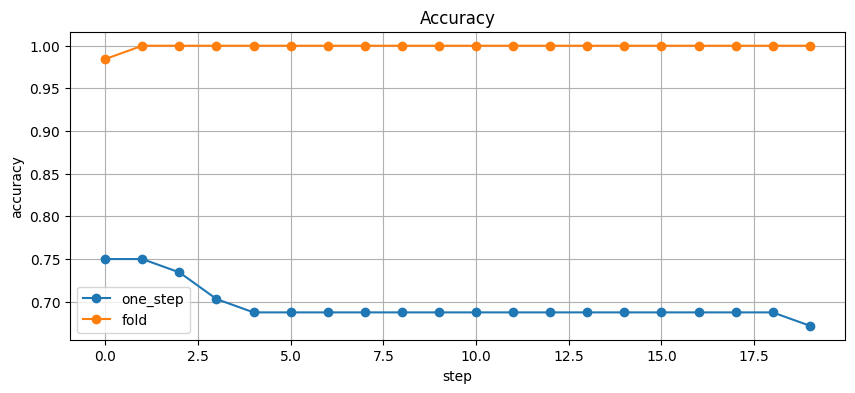

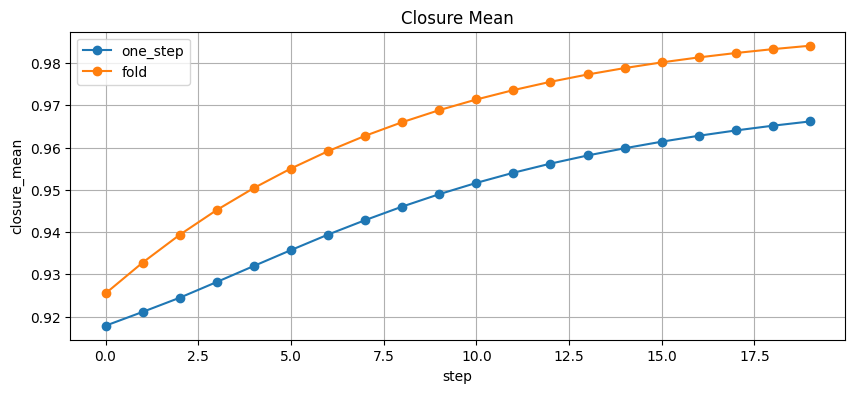

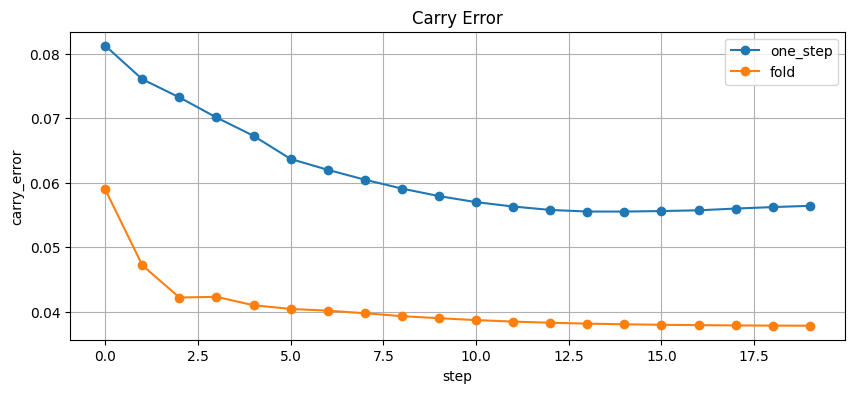

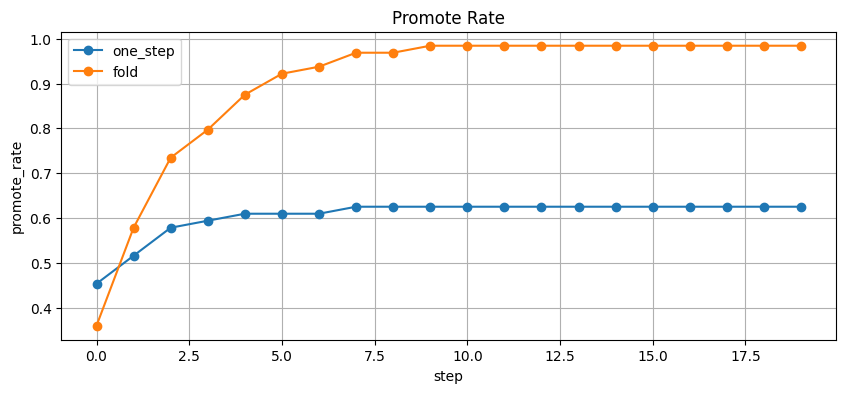

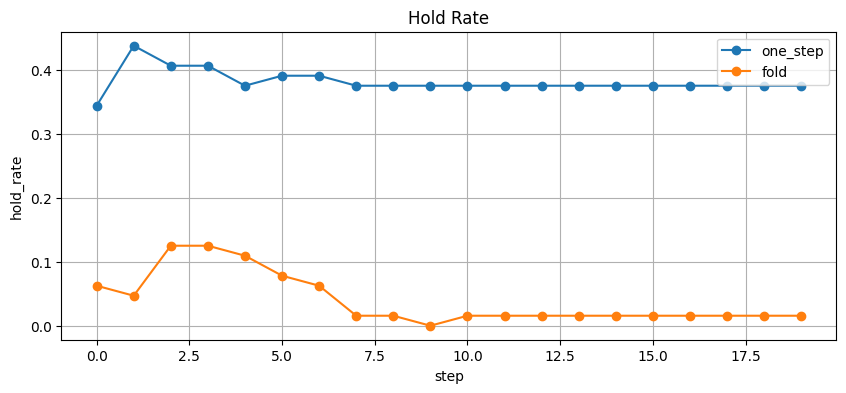

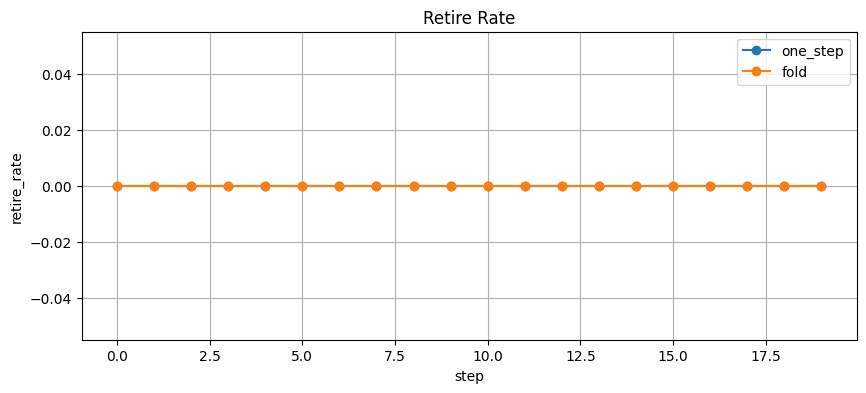

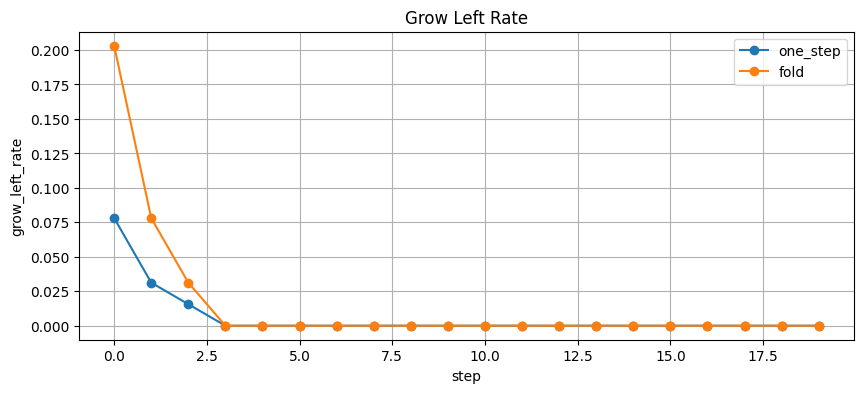

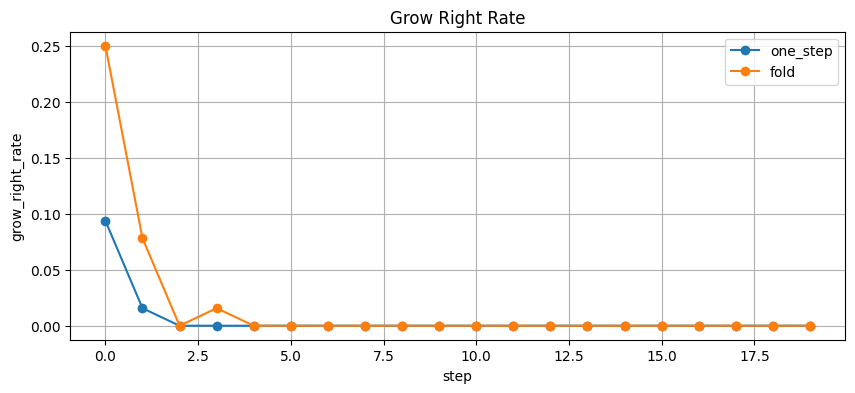

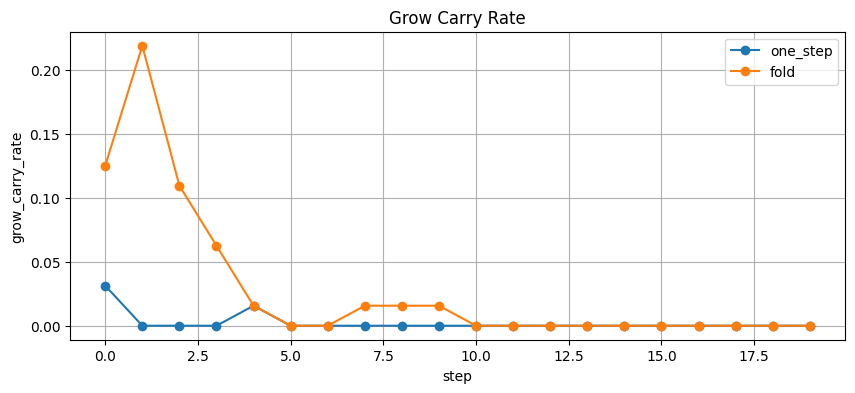

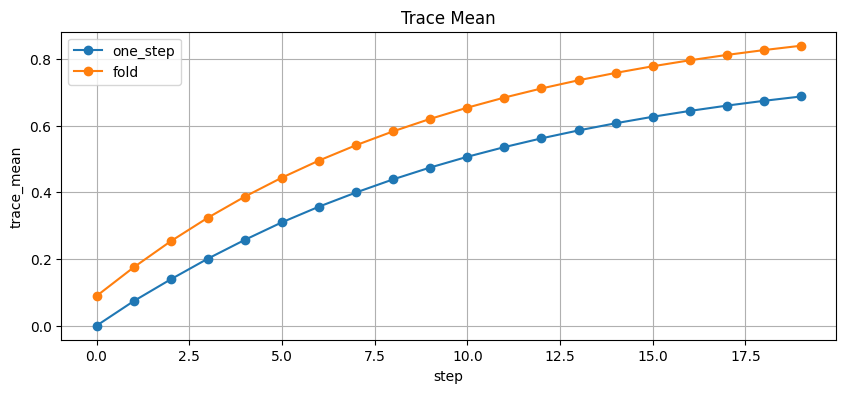

In [9]:

metrics = [
    "accuracy",
    "closure_mean",
    "carry_error",
    "promote_rate",
    "hold_rate",
    "retire_rate",
    "grow_left_rate",
    "grow_right_rate",
    "grow_carry_rate",
    "trace_mean",
]

for metric in metrics:
    plt.figure(figsize=(10, 4))
    for mode in ["one_step", "fold"]:
        df = compare_df[compare_df["mode"] == mode]
        plt.plot(df["step"], df[metric], marker="o", label=mode)
    plt.title(metric.replace("_", " ").title())
    plt.xlabel("step")
    plt.ylabel(metric)
    plt.legend(loc="best")
    plt.show()



## Final comparison


In [10]:

final_compare = pd.DataFrame([{
    "one_step_final_accuracy": float(one_df.iloc[-1]["accuracy"]),
    "fold_final_accuracy": float(fold_df.iloc[-1]["accuracy"]),
    "one_step_final_closure": float(one_df.iloc[-1]["closure_mean"]),
    "fold_final_closure": float(fold_df.iloc[-1]["closure_mean"]),
    "one_step_final_carry_error": float(one_df.iloc[-1]["carry_error"]),
    "fold_final_carry_error": float(fold_df.iloc[-1]["carry_error"]),
    "one_step_final_promote_rate": float(one_df.iloc[-1]["promote_rate"]),
    "fold_final_promote_rate": float(fold_df.iloc[-1]["promote_rate"]),
    "one_step_final_grow_carry_rate": float(one_df.iloc[-1]["grow_carry_rate"]),
    "fold_final_grow_carry_rate": float(fold_df.iloc[-1]["grow_carry_rate"]),
}])
final_compare


,one_step_final_accuracy,fold_final_accuracy,one_step_final_closure,fold_final_closure,one_step_final_carry_error,fold_final_carry_error,one_step_final_promote_rate,fold_final_promote_rate,one_step_final_grow_carry_rate,fold_final_grow_carry_rate
0,0.671875,1.0,0.966164,0.984066,0.056411,0.037802,0.625,0.984375,0.0,0.0



## Practical readout

If the folding controller improves:
- closure
- carry error
- stability of the packet field

then the next turn is clear:

- keep the recurrent lattice
- keep forward projection
- keep backward correction
- keep forward folding
- replace synthetic truth with real proposal traces

This is the protein-like folding version of the bridge runtime.
